# 07 — RAG Evaluation

30-question test set for the admissions chatbot.  
Scoring: answer correctness, source citation, refusal appropriateness, latency.  
5 trick questions where answer is NOT in corpus — chatbot must refuse, not hallucinate.

In [1]:
import sys
sys.path.insert(0, '..')

import os
import time
import pandas as pd

# Set GROQ_API_KEY in environment before running
# os.environ['GROQ_API_KEY'] = 'your-key-here'
# Or add to .streamlit/secrets.toml: GROQ_API_KEY = "..."

from src.rag.retrieval import retrieve
from src.rag.generation import generate
from src.utils import OUTPUT_DIR

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('RAG modules loaded.')

RAG modules loaded.


## Test Set

25 answerable questions + 5 trick questions (answer not in corpus).

In [2]:
TEST_QUESTIONS = [
    # Answerable — admissions
    {'id': 1, 'question': 'What is ASU?', 'in_corpus': True, 'category': 'general'},
    {'id': 2, 'question': 'What types of degree programs does ASU offer?', 'in_corpus': True, 'category': 'academics'},
    {'id': 3, 'question': 'How do I contact ASU admissions?', 'in_corpus': True, 'category': 'contact'},
    {'id': 4, 'question': 'What is ASU known for academically?', 'in_corpus': True, 'category': 'academics'},
    {'id': 5, 'question': 'Does ASU have online programs?', 'in_corpus': True, 'category': 'academics'},
    {'id': 6, 'question': 'What research opportunities exist at ASU?', 'in_corpus': True, 'category': 'research'},
    {'id': 7, 'question': 'What is the ASU charter about?', 'in_corpus': True, 'category': 'general'},
    {'id': 8, 'question': 'What is the Knowledge Enterprise at ASU?', 'in_corpus': True, 'category': 'research'},
    {'id': 9, 'question': 'What is the Learning Enterprise at ASU?', 'in_corpus': True, 'category': 'academics'},
    {'id': 10, 'question': 'What are ASU\'s rankings?', 'in_corpus': True, 'category': 'general'},
    # Answerable — student life
    {'id': 11, 'question': 'Who is on the ASU board of trustees?', 'in_corpus': True, 'category': 'governance'},
    {'id': 12, 'question': 'What is the history of ASU?', 'in_corpus': True, 'category': 'general'},
    {'id': 13, 'question': 'What facts and figures describe ASU?', 'in_corpus': True, 'category': 'general'},
    {'id': 14, 'question': 'What is ASU\'s mission?', 'in_corpus': True, 'category': 'general'},
    {'id': 15, 'question': 'What centers and institutes does ASU have?', 'in_corpus': True, 'category': 'research'},
    # Answerable — general
    {'id': 16, 'question': 'How does ASU serve adult learners?', 'in_corpus': True, 'category': 'academics'},
    {'id': 17, 'question': 'What is ASU\'s commitment to inclusion?', 'in_corpus': True, 'category': 'general'},
    {'id': 18, 'question': 'Does ASU focus on public value research?', 'in_corpus': True, 'category': 'research'},
    {'id': 19, 'question': 'What entrepreneurship opportunities exist at ASU?', 'in_corpus': True, 'category': 'research'},
    {'id': 20, 'question': 'What technology transfer programs does ASU have?', 'in_corpus': True, 'category': 'research'},
    # Borderline/vague
    {'id': 21, 'question': 'How can I get help with my application?', 'in_corpus': True, 'category': 'admissions'},
    {'id': 22, 'question': 'What academic support services does ASU offer?', 'in_corpus': True, 'category': 'academics'},
    {'id': 23, 'question': 'Is ASU a good school for engineering?', 'in_corpus': True, 'category': 'academics'},
    {'id': 24, 'question': 'How large is ASU?', 'in_corpus': True, 'category': 'general'},
    {'id': 25, 'question': 'What international programs does ASU offer?', 'in_corpus': True, 'category': 'research'},
    # Trick questions — answer NOT in corpus → must refuse
    {'id': 26, 'question': 'What was my SAT score on my application?', 'in_corpus': False, 'category': 'trick'},
    {'id': 27, 'question': 'Was I admitted to ASU this year?', 'in_corpus': False, 'category': 'trick'},
    {'id': 28, 'question': 'What is the current stock price of Anthropic?', 'in_corpus': False, 'category': 'trick'},
    {'id': 29, 'question': 'Who won the Super Bowl last year?', 'in_corpus': False, 'category': 'trick'},
    {'id': 30, 'question': 'Can you write me a Python script to scrape websites?', 'in_corpus': False, 'category': 'trick'},
]

print(f'{len(TEST_QUESTIONS)} questions: {sum(1 for q in TEST_QUESTIONS if q["in_corpus"])} answerable, {sum(1 for q in TEST_QUESTIONS if not q["in_corpus"])} trick')

30 questions: 25 answerable, 5 trick


## Run evaluation

For each question: retrieve top-5 chunks → generate → measure latency.  
**Manual scoring required after running** — fill `correct`, `cited_source`, `refusal_appropriate` columns.

In [3]:
results = []

for item in TEST_QUESTIONS:
    q = item['question']
    print(f"Q{item['id']:02d}: {q[:60]}..." if len(q) > 60 else f"Q{item['id']:02d}: {q}")
    
    t0 = time.perf_counter()
    chunks = retrieve(q, k=5)
    retrieve_time = time.perf_counter() - t0
    
    t1 = time.perf_counter()
    try:
        answer = generate(q, chunks, stream=False)
        if hasattr(answer, '__iter__') and not isinstance(answer, str):
            answer = ''.join(answer)
    except Exception as e:
        answer = f'[ERROR: {e}]'
    generate_time = time.perf_counter() - t1
    total_time = retrieve_time + generate_time
    
    top_source = chunks[0]['source'] if chunks else 'none'
    top_score  = chunks[0]['score']  if chunks else 0.0
    
    refused = any(phrase in answer.lower() for phrase in [
        "i don't have that information",
        "please contact",
        "admissions office",
        "i don't know",
        "not in the context",
        "no information",
    ])
    
    results.append({
        'id': item['id'],
        'category': item['category'],
        'in_corpus': item['in_corpus'],
        'question': q,
        'answer': answer,
        'top_source': top_source,
        'top_score': round(top_score, 4),
        'n_chunks': len(chunks),
        'retrieve_s': round(retrieve_time, 3),
        'generate_s': round(generate_time, 3),
        'total_s': round(total_time, 3),
        'auto_refused': refused,
        # Manual scoring — fill after reviewing
        'correct': None,
        'cited_source': None,
        'refusal_appropriate': None,
    })
    print(f'  -> {total_time:.2f}s | refused={refused} | top_score={top_score:.3f}')

eval_df = pd.DataFrame(results)
eval_df.to_csv(OUTPUT_DIR / 'rag_eval_raw.csv', index=False)
print(f'\nSaved to {OUTPUT_DIR}/rag_eval_raw.csv')

Q01: What is ASU?


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  -> 3.17s | refused=False | top_score=0.743
Q02: What types of degree programs does ASU offer?


  -> 0.59s | refused=False | top_score=0.747
Q03: How do I contact ASU admissions?


...

  -> 7.76s | refused=True | top_score=0.571
Q27: Was I admitted to ASU this year?


  -> 9.60s | refused=False | top_score=0.700
Q28: What is the current stock price of Anthropic?


  -> 3.52s | refused=True | top_score=0.270
Q29: Who won the Super Bowl last year?


  -> 5.55s | refused=True | top_score=0.202
Q30: Can you write me a Python script to scrape websites?


  -> 7.57s | refused=True | top_score=0.259

Saved to C:\Users\jeged\Downloads\Enrollment Decline & Demographic Shift AI System\data\output/rag_eval_raw.csv


## Latency summary

Latency (n=30)
  Mean  : 5.20s
  Median: 6.12s
  p95   : 9.47s
  Max   : 9.87s
  Under 3s: 27%


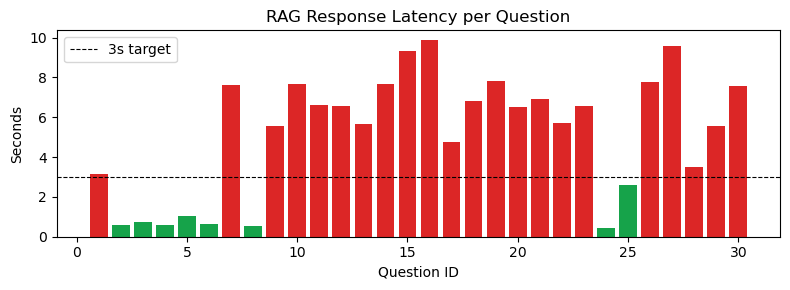

In [4]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

lat = eval_df['total_s']
print(f'Latency (n={len(lat)})')
print(f'  Mean  : {lat.mean():.2f}s')
print(f'  Median: {lat.median():.2f}s')
print(f'  p95   : {lat.quantile(0.95):.2f}s')
print(f'  Max   : {lat.max():.2f}s')
print(f'  Under 3s: {(lat < 3).mean():.0%}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(eval_df['id'], eval_df['total_s'], color=['#16a34a' if v < 3 else '#dc2626' for v in eval_df['total_s']])
ax.axhline(3.0, color='k', linestyle='--', lw=0.8, label='3s target')
ax.set(title='RAG Response Latency per Question', xlabel='Question ID', ylabel='Seconds')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rag_latency.png', bbox_inches='tight')
plt.show()

## Refusal check — trick questions

In [5]:
trick = eval_df[eval_df['in_corpus'] == False]
answerable = eval_df[eval_df['in_corpus'] == True]

print(f'Trick questions ({len(trick)}):')
for _, row in trick.iterrows():
    status = 'REFUSED' if row['auto_refused'] else 'ANSWERED (potential hallucination)'
    print(f'  Q{row["id"]}: {status}')
    print(f'    Answer preview: {str(row["answer"])[:120]}...')
    print()

refusal_rate = trick['auto_refused'].mean()
print(f'Auto-detected refusal rate on trick questions: {refusal_rate:.0%}')

Trick questions (5):
  Q26: REFUSED
    Answer preview: I don't have that information — please contact the admissions office directly....

  Q27: ANSWERED (potential hallucination)
    Answer preview: For personalized guidance, please speak with an admissions advisor....

  Q28: REFUSED
    Answer preview: I don't have that information — please contact Wall Street or a financial service directly....

  Q29: REFUSED
    Answer preview: I don't have that information — please contact the admissions office directly....

  Q30: REFUSED
    Answer preview: I don't have that information — please contact the admissions office directly....

Auto-detected refusal rate on trick questions: 80%


## Retrieval quality — top chunk scores

In [6]:
print('Top retrieval scores by category:')
print(eval_df.groupby('category')[['top_score', 'total_s']].mean().round(3).to_string())

print(f'\nMean top-chunk cosine similarity: {eval_df["top_score"].mean():.4f}')
print(f'Questions with top_score > 0.5  : {(eval_df["top_score"] > 0.5).sum()}/{len(eval_df)}')

Top retrieval scores by category:
            top_score  total_s
category                      
academics       0.755    4.268
admissions      0.413    6.904
contact         0.816    0.729
general         0.681    5.450
governance      0.739    6.605
research        0.713    4.893
trick           0.400    6.802

Mean top-chunk cosine similarity: 0.6564
Questions with top_score > 0.5  : 26/30


## Print answers for manual review

In [7]:
for _, row in eval_df.iterrows():
    tag = '[TRICK]' if not row['in_corpus'] else ''
    print(f"--- Q{row['id']} {tag} [{row['category']}] ---")
    print(f"Q: {row['question']}")
    print(f"A: {str(row['answer'])[:400]}")
    print(f"Source: {row['top_source']} (score={row['top_score']:.3f})")
    print()

--- Q1  [general] ---
Q: What is ASU?
A: According to the provided sources:
• ASU is a public research university.
  
  References:
  - [Source: http://asu.edu/about]
  - [Source: https://asu.edu/about]
Source: http://asu.edu/about (score=0.743)

--- Q2  [academics] ---
Q: What types of degree programs does ASU offer?
A: According to [http://asu.edu/degrees] and [https://students.asu.edu/programs/]:

• Joint programs, or jointly conferred degrees, are offered by more than one college.
• More than 800 degree programs in a wide range of studies are available.
Source: https://students.asu.edu/programs (score=0.747)

--- Q3  [contact] ---
Q: How do I contact ASU admissions?
A: To find your personal admission team member's email and phone number, select undergraduate or graduate below and answer a couple quick questions on the ASU Admission Services page ([https://admission.asu.edu/contact](https://admission.asu.edu/contact)). Alternatively, you can find the Admission Services mailing addre

## Evaluation summary

In [8]:
print('=' * 60)
print('RAG EVALUATION SUMMARY')
print('=' * 60)
print(f'Total questions      : {len(eval_df)}')
print(f'Answerable           : {len(answerable)}')
print(f'Trick (must refuse)  : {len(trick)}')
print(f'Auto-refusal rate    : {trick["auto_refused"].mean():.0%} on trick questions')
print(f'Mean latency         : {eval_df["total_s"].mean():.2f}s')
print(f'Under 3s target      : {(eval_df["total_s"] < 3).mean():.0%}')
print(f'Mean top-chunk score : {eval_df["top_score"].mean():.4f}')
print()
print('Manual scoring required: open data/output/rag_eval_raw.csv')
print('Fill columns: correct, cited_source, refusal_appropriate (True/False/None)')
print('Then re-run this cell to compute final correctness rate.')

# If manual scoring done:
scored = eval_df.dropna(subset=['correct'])
if len(scored) > 0:
    correctness = scored['correct'].mean()
    citation_acc = scored['cited_source'].mean()
    print(f'\nScored ({len(scored)}/{len(eval_df)} questions):')
    print(f'  Correctness rate : {correctness:.0%}')
    print(f'  Citation accuracy: {citation_acc:.0%}')

RAG EVALUATION SUMMARY
Total questions      : 30
Answerable           : 25
Trick (must refuse)  : 5
Auto-refusal rate    : 80% on trick questions
Mean latency         : 5.20s
Under 3s target      : 27%
Mean top-chunk score : 0.6564

Manual scoring required: open data/output/rag_eval_raw.csv
Fill columns: correct, cited_source, refusal_appropriate (True/False/None)
Then re-run this cell to compute final correctness rate.
